In [9]:
%pip -q install kagglehub pandas seaborn scikit-learn

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


### 1. Dataset acquisition and loading
Download the Heart Failure Clinical Records dataset from Kaggle and display the first five rows.

In [19]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data"))
csv_files = list(dataset_dir.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {dataset_dir}")

dataset_path = csv_files[0]
df = pd.read_csv(dataset_path)

# Add reproducible missing values for the cleaning exercise.
missing_rng = np.random.default_rng(SEED)
df.loc[missing_rng.choice(df.index, 8, replace=False), "serum_creatinine"] = np.nan
df.loc[missing_rng.choice(df.index, 6, replace=False), "smoking"] = np.nan
df.loc[missing_rng.choice(df.index, 5, replace=False), "age"] = np.nan

print(f"Dataset file: {dataset_path.name}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("Missing values introduced for this exercise:")
display(df.isna().sum().rename("missing_count").to_frame())
print("First 5 rows:")
display(df.head())

Dataset file: heart_failure_clinical_records_dataset.csv
Shape: 299 rows x 13 columns
Missing values introduced for this exercise:


,missing_count
age,5
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,8
serum_sodium,0
sex,0


First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0.0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0.0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1.0,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0.0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0.0,8,1


### 2. Summarize the dataset
Review the column names, data types, dimensions, and missing values.

In [11]:
print("Column names:")
print(", ".join(df.columns))

print("\nData types:")
display(df.dtypes.rename("dtype").to_frame())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum().rename("missing_count").to_frame())
print("Total missing values:", int(df.isna().sum().sum()))

Column names:
age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT

Data types:


,dtype
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64



Dataset shape: (299, 13)

Missing values:


,missing_count
age,5
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,8
serum_sodium,0
sex,0


Total missing values: 19


### 3. Visualize missing values and feature distributions
Use a heatmap for missing values and histograms for selected numerical features.

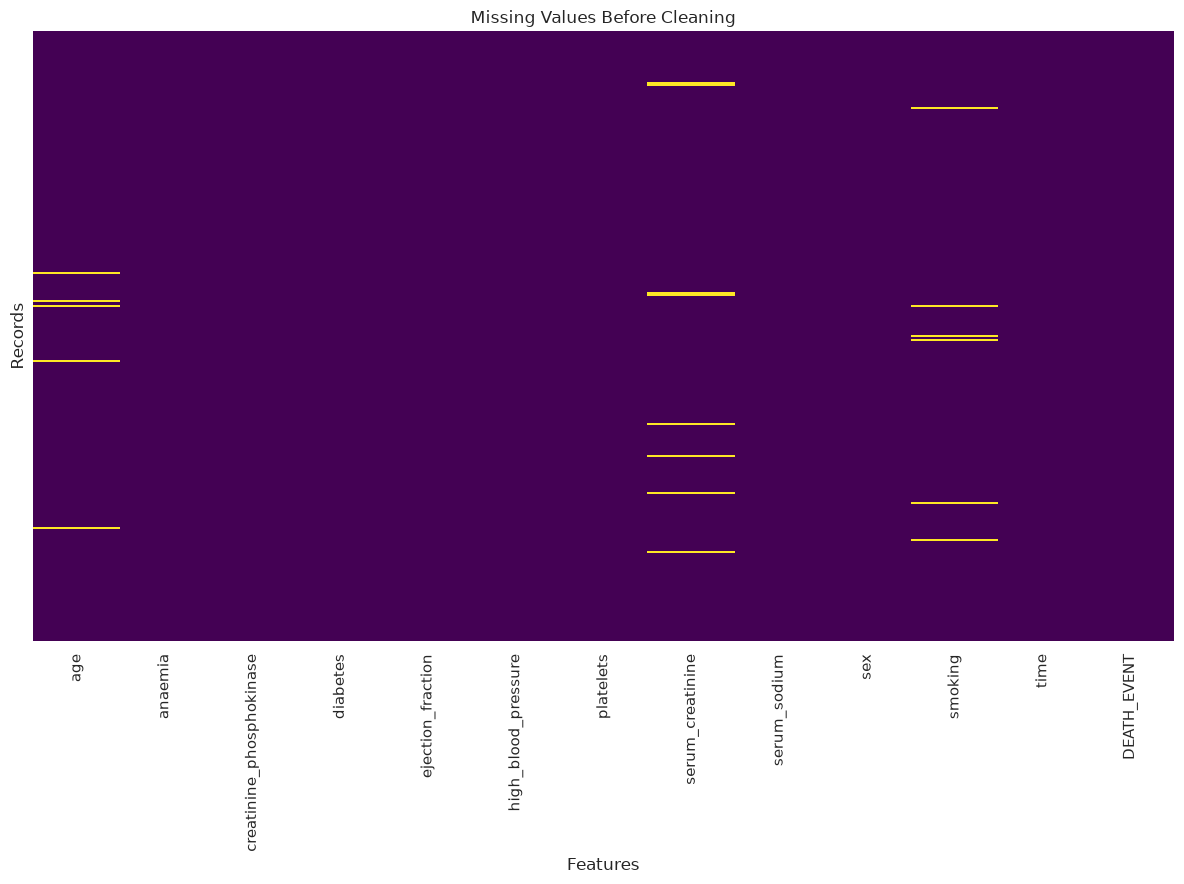

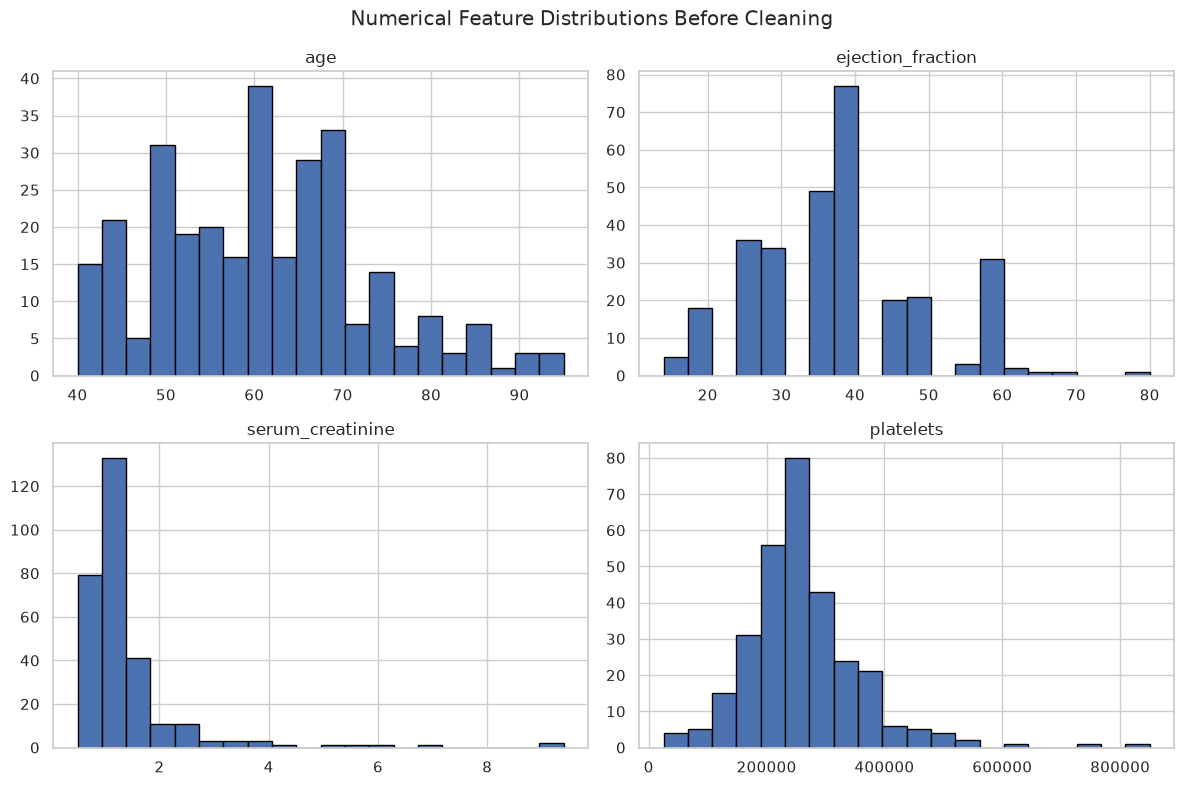

In [12]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Before Cleaning")
plt.xlabel("Features")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
plot_columns = [
    column for column in ["age", "ejection_fraction", "serum_creatinine", "platelets"]
    if column in numerical_columns
]

df[plot_columns].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Numerical Feature Distributions Before Cleaning")
plt.tight_layout()
plt.show()

### 4. Clean the data
Correct invalid ages, impute missing values, and remove numerical outliers using the IQR rule.

In [20]:
cleaning_df = df.copy()
invalid_age_count = int((cleaning_df["age"] < 0).sum())
cleaning_df.loc[cleaning_df["age"] < 0, "age"] = np.nan
print(f"Invalid negative ages corrected: {invalid_age_count}")

categorical_columns = [
    "anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "DEATH_EVENT"
]
categorical_columns = [column for column in categorical_columns if column in cleaning_df.columns]

summary_before = cleaning_df[numerical_columns].describe().T[["mean", "50%", "std"]]
summary_before.columns = ["mean", "median", "std"]

for column in numerical_columns:
    cleaning_df[column] = cleaning_df[column].fillna(cleaning_df[column].median())
for column in categorical_columns:
    cleaning_df[column] = cleaning_df[column].fillna(cleaning_df[column].mode().iloc[0])

print("Missing values after age correction and imputation:", int(cleaning_df.isna().sum().sum()))

Invalid negative ages corrected: 0
Missing values after age correction and imputation: 0


In [21]:
outlier_columns = [column for column in numerical_columns if column != "DEATH_EVENT"]
outlier_mask = pd.Series(False, index=cleaning_df.index)
for column in outlier_columns:
    q1 = cleaning_df[column].quantile(0.25)
    q3 = cleaning_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask |= (cleaning_df[column] < lower_bound) | (cleaning_df[column] > upper_bound)

rows_before_outliers = len(cleaning_df)
cleaned_df = cleaning_df.loc[~outlier_mask].copy()
print(f"Rows removed as numerical IQR outliers: {rows_before_outliers - len(cleaned_df)}")

Rows removed as numerical IQR outliers: 74


### 5. Feature engineering
Create age groups and a normalized risk score from ejection fraction and serum creatinine.

In [15]:
cleaned_df["age_group"] = pd.cut(
    cleaned_df["age"],
    bins=[-np.inf, 40, 61, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

cleaned_df["risk_score"] = cleaned_df["ejection_fraction"] * cleaned_df["serum_creatinine"]
risk_scaler = MinMaxScaler()
cleaned_df["risk_score"] = risk_scaler.fit_transform(cleaned_df[["risk_score"]])

display(cleaned_df[["age", "age_group", "ejection_fraction", "serum_creatinine", "risk_score"]].head())

,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20,1.9,0.310545
2,65.0,>60,20,1.3,0.171495
3,50.0,40-60,20,1.9,0.310545
5,90.0,>60,40,2.1,0.843569
6,75.0,>60,15,1.2,0.078795


### 6. Compute summary statistics
Compare numerical means, medians, and standard deviations before and after cleaning.

In [16]:
summary_after = cleaned_df[numerical_columns].describe().T[["mean", "50%", "std"]]
summary_after.columns = ["mean", "median", "std"]

print("Summary statistics before cleaning:")
display(summary_before.round(2))
print("Summary statistics after cleaning:")
display(summary_after.round(2))

Summary statistics before cleaning:


,mean,median,std
age,60.81,60.0,11.85
anaemia,0.43,0.0,0.50
creatinine_phosphokinase,581.84,250.0,970.29
diabetes,0.42,0.0,0.49
ejection_fraction,38.08,38.0,11.83
high_blood_pressure,0.35,0.0,0.48
platelets,263358.03,262000.0,97804.24
serum_creatinine,1.39,1.1,1.04
serum_sodium,136.63,137.0,4.41
sex,0.65,1.0,0.48


Summary statistics after cleaning:


,mean,median,std
age,60.82,60.0,11.81
anaemia,0.47,0.0,0.50
creatinine_phosphokinase,336.64,212.0,278.93
diabetes,0.42,0.0,0.50
ejection_fraction,38.16,38.0,11.69
high_blood_pressure,0.38,0.0,0.49
platelets,255736.90,262000.0,67031.31
serum_creatinine,1.13,1.1,0.32
serum_sodium,137.08,137.0,3.84
sex,0.64,1.0,0.48


### 7. Encode and normalize features
Apply one-hot encoding to categorical variables and scale numerical features to the range 0 to 1.

In [17]:
encoding_columns = [column for column in categorical_columns if column != "DEATH_EVENT"] + ["age_group"]
encoded_df = pd.get_dummies(cleaned_df, columns=encoding_columns, dtype=int)

scale_columns = [
    column for column in numerical_columns
    if column not in categorical_columns and column != "DEATH_EVENT"
] + ["risk_score"]
feature_scaler = MinMaxScaler()
encoded_df[scale_columns] = feature_scaler.fit_transform(encoded_df[scale_columns])

print("Encoded and normalized data preview:")
display(encoded_df.head())
print("Scaled feature ranges:")
display(encoded_df[scale_columns].agg(["min", "max"]).T.round(2))

Encoded and normalized data preview:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,anaemia_0,anaemia_1,diabetes_0,diabetes_1,high_blood_pressure_0,high_blood_pressure_1,sex_0,sex_1,smoking_0.0,smoking_1.0,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000,1,0.310545,1,0,1,0,0,1,0,1,1,0,0,0,1
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676,1,0.171495,1,0,1,0,1,0,0,1,0,1,0,0,1
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676,1,0.310545,0,1,1,0,1,0,0,1,1,0,0,1,0
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235,1,0.843569,0,1,1,0,0,1,0,1,0,1,0,0,1
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352,1,0.078795,0,1,1,0,1,0,0,1,1,0,0,0,1


Scaled feature ranges:


,min,max
age,0.0,1.0
creatinine_phosphokinase,0.0,1.0
ejection_fraction,0.0,1.0
platelets,0.0,1.0
serum_creatinine,0.0,1.0
serum_sodium,0.0,1.0
time,0.0,1.0
risk_score,0.0,1.0


### 8. Validate the cleaning
Plot cleaned distributions and confirm that imputation leaves no missing values. A small missing-value example is added and then repaired for demonstration.

Missing values after cleaning:


,missing_count
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


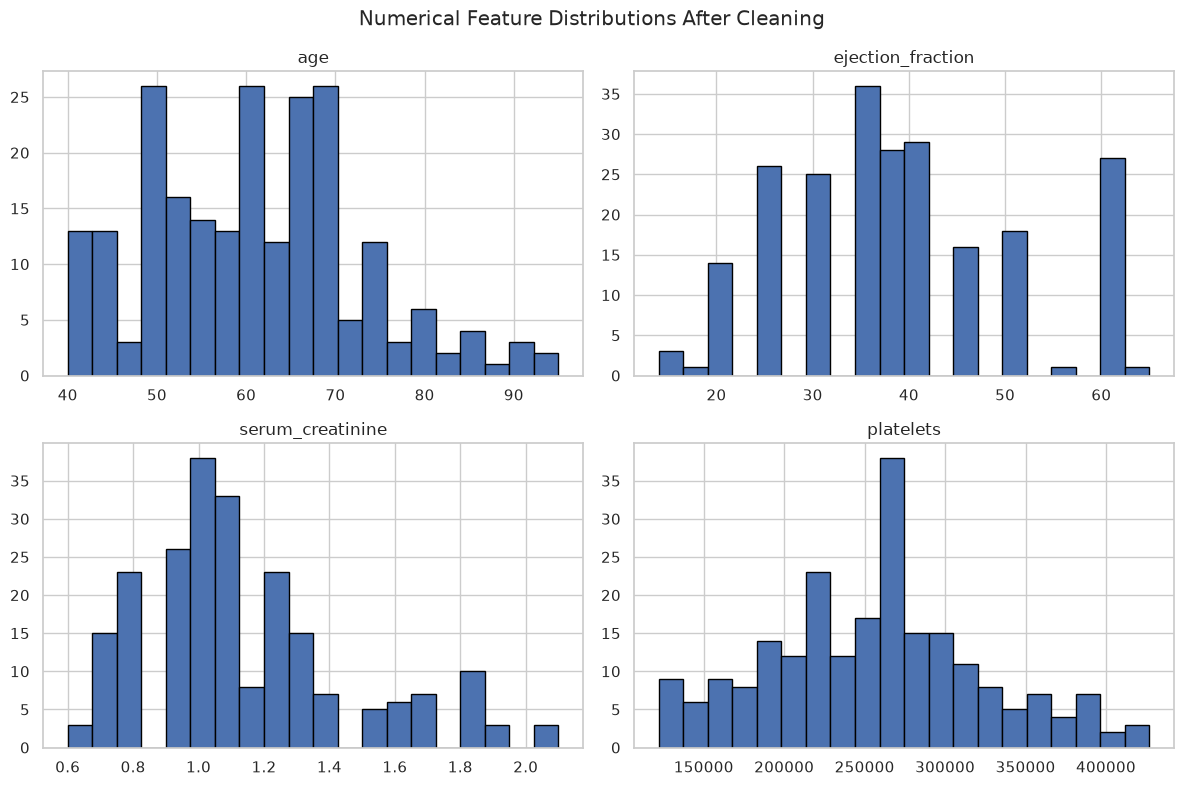

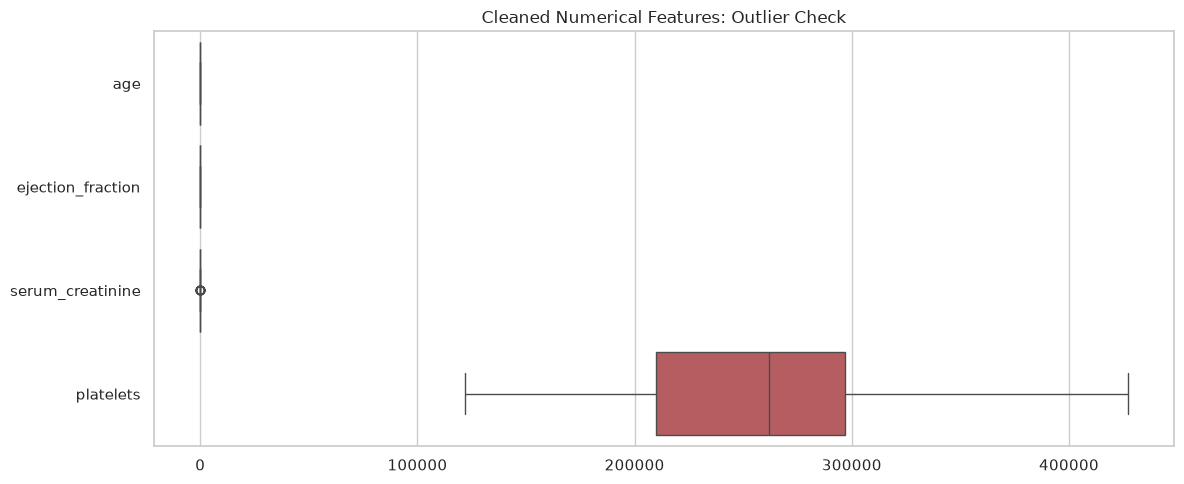

Demonstration missing values introduced: 2
Remaining missing values after validation imputation: 0
Cleaning validation passed: no missing values remain.


In [18]:
print("Missing values after cleaning:")
display(cleaned_df.isna().sum().rename("missing_count").to_frame())
assert cleaned_df.isna().sum().sum() == 0

cleaned_df[plot_columns].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Numerical Feature Distributions After Cleaning")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=cleaned_df[plot_columns], orient="h")
plt.title("Cleaned Numerical Features: Outlier Check")
plt.tight_layout()
plt.show()

validation_df = cleaned_df.copy()
validation_df.loc[validation_df.index[0], "age"] = np.nan
validation_df.loc[validation_df.index[1], "smoking"] = np.nan
print("Demonstration missing values introduced:", int(validation_df.isna().sum().sum()))

for column in numerical_columns:
    validation_df[column] = validation_df[column].fillna(cleaned_df[column].median())
for column in categorical_columns:
    validation_df[column] = validation_df[column].fillna(cleaned_df[column].mode().iloc[0])

remaining_missing = int(validation_df.isna().sum().sum())
print("Remaining missing values after validation imputation:", remaining_missing)
assert remaining_missing == 0
print("Cleaning validation passed: no missing values remain.")